In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/eserkaraceper/galatasaray-twitter-sentiment-analysis/tweets_sentiment_masked.csv


In [2]:
import pandas as pd
from transformers import pipeline

df = pd.read_csv("/kaggle/input/datasets/eserkaraceper/galatasaray-twitter-sentiment-analysis/tweets_sentiment_masked.csv")

# Türkçe sentiment modeli
sentiment_model = pipeline(
    "text-classification",
    model="savasy/bert-base-turkish-sentiment-cased",
    truncation=True,
    max_length=512
)

print(f"✅ {len(df)} satır yüklendi, model hazır")

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ 1695 satır yüklendi, model hazır


In [3]:
def analyze(text):
    try:
        result = sentiment_model(str(text)[:512])[0]
        label = result["label"]   # "positive" veya "negative"
        score = result["score"]   # güven skoru (0-1)
        return label, score
    except:
        return "notr", 0.5

print("Skorlanıyor... (~5-10 dk sürebilir)")

results = df["clean_text"].apply(analyze)
df["label_raw"] = results.apply(lambda x: x[0])
df["confidence"] = results.apply(lambda x: x[1])

print("✅ Bitti")

Skorlanıyor... (~5-10 dk sürebilir)
✅ Bitti


In [4]:
def map_label(row):
    if row["confidence"] < 0.65:   # düşük güven → nötr
        return "Nötr"
    elif row["label_raw"] == "positive":
        return "Pozitif"
    else:
        return "Negatif"

df["sentiment"] = df.apply(map_label, axis=1)

print(df["sentiment"].value_counts())
print(df["sentiment"].value_counts(normalize=True).mul(100).round(1))
df[["text", "sentiment", "confidence"]].head(10)

sentiment
Negatif    1019
Pozitif     498
Nötr        178
Name: count, dtype: int64
sentiment
Negatif    60.1
Pozitif    29.4
Nötr       10.5
Name: proportion, dtype: float64


,text,sentiment,confidence
0,Yav sktrin gidin amk sokacam artık da,Nötr,0.538618
1,bu lesley magassa masalı da 1-2 hafta sorer ge...,Negatif,0.853064
2,#DursunÖzbekParalarNerede,Negatif,0.810933
3,Can -Lesley -Reijnders Can 10 no Lesley 6 Reij...,Pozitif,0.985296
4,Samiyen haberden gör burda gir iyi la 😀😀,Pozitif,0.844890
5,aniden düşen güzel haberler,Nötr,0.575131
6,La siz yalan soyluyonuz inanmiyom hicbirinize,Negatif,0.726683
7,Şu an yaşadıklarımızın rüya olduğunu eylül baş...,Nötr,0.581698
8,Yav şu 23 yaş üstü kontenjanı iyi birini alıp ...,Negatif,0.996077
9,Yalan olduğunu bilsem de inanmak istiyorum,Pozitif,0.953831


In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("/kaggle/input/datasets/eserkaraceper/galatasaray-twitter-sentiment-analysis/tweets_sentiment_masked.csv")
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
print(f"✅ {len(df)} satır yüklendi")

✅ 1695 satır yüklendi


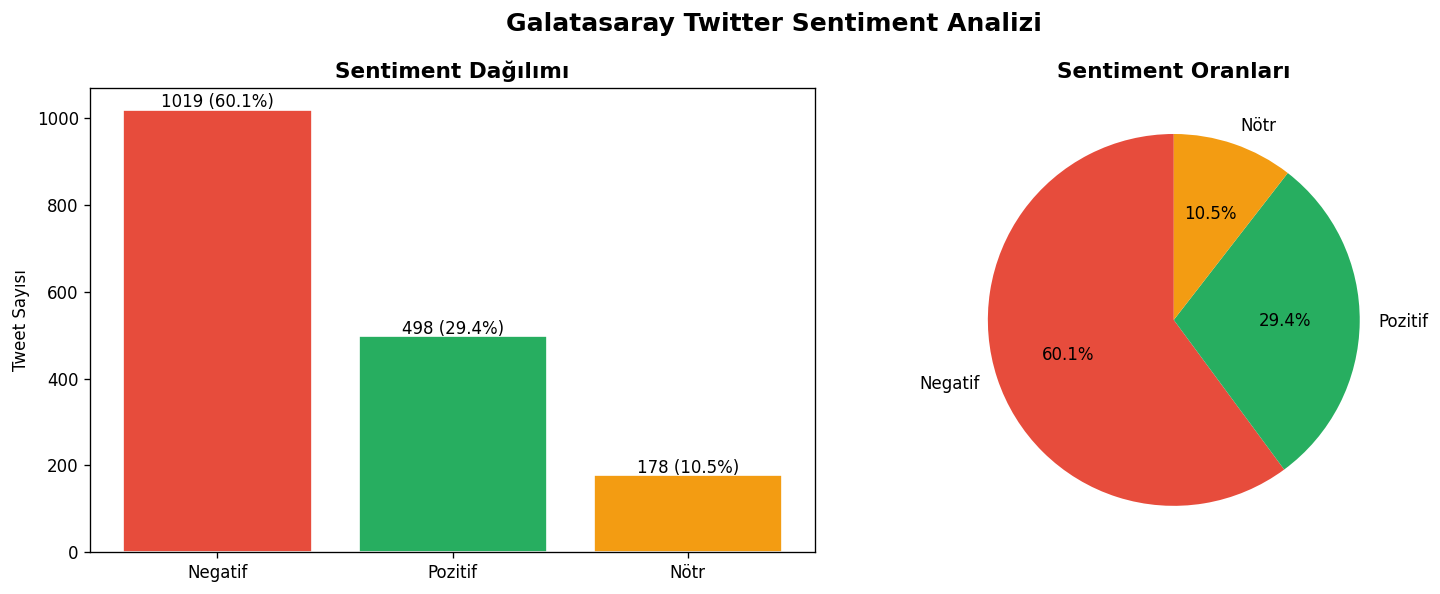

In [6]:
colors = {"Pozitif": "#27ae60", "Nötr": "#f39c12", "Negatif": "#e74c3c"}
counts = df["sentiment"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bar_c = [colors[s] for s in counts.index]
axes[0].bar(counts.index, counts.values, color=bar_c, edgecolor="white")
axes[0].set_title("Sentiment Dağılımı", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Tweet Sayısı")
for i, (l, v) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, v + 5, f"{v} ({v/len(df)*100:.1f}%)", ha="center", fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=[colors[s] for s in counts.index],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Sentiment Oranları", fontsize=13, fontweight="bold")

plt.suptitle("Galatasaray Twitter Sentiment Analizi", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

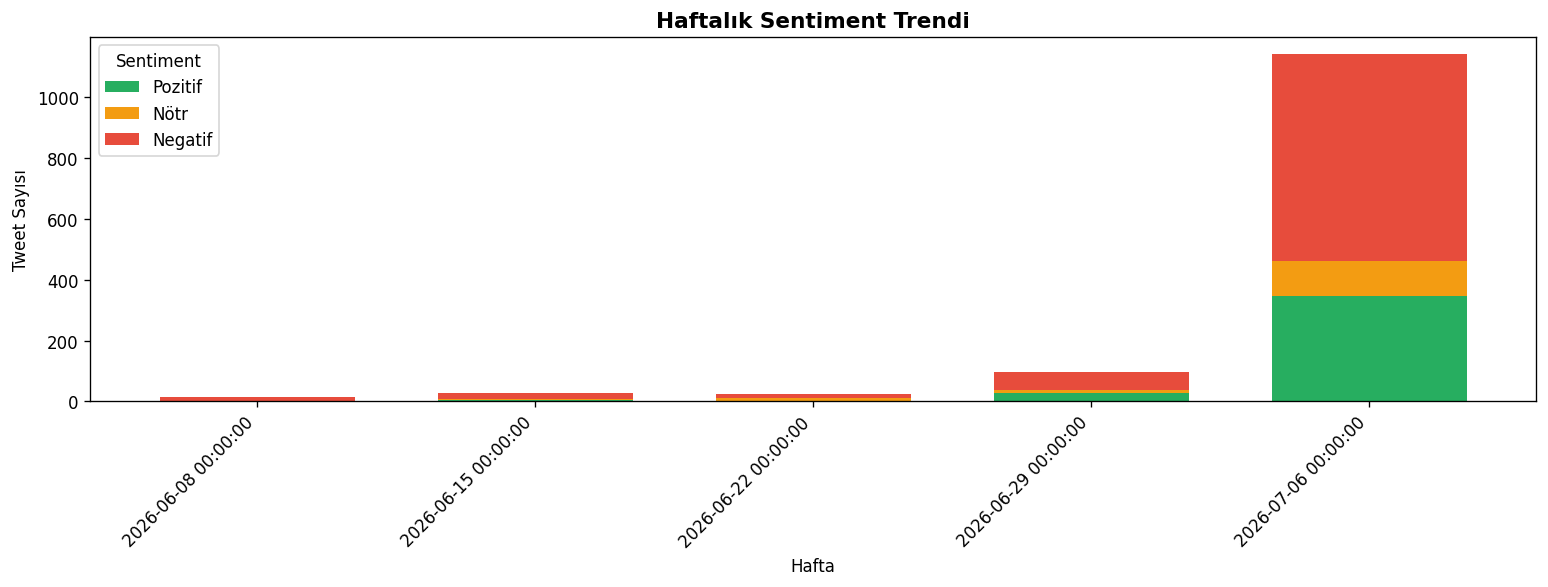

In [7]:
son_30 = df[df["created_at"] >= df["created_at"].max() - pd.Timedelta(days=30)]
son_30["week"] = son_30["created_at"].dt.to_period("W").dt.start_time
weekly = (son_30.groupby(["week", "sentiment"]).size().unstack(fill_value=0)
            .reindex(columns=["Pozitif", "Nötr", "Negatif"], fill_value=0))

fig, ax = plt.subplots(figsize=(13, 5))
weekly.plot(kind="bar", stacked=True, ax=ax,
            color=["#27ae60", "#f39c12", "#e74c3c"], width=0.7)
ax.set_title("Haftalık Sentiment Trendi", fontsize=13, fontweight="bold")
ax.set_xlabel("Hafta")
ax.set_ylabel("Tweet Sayısı")
ax.legend(title="Sentiment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

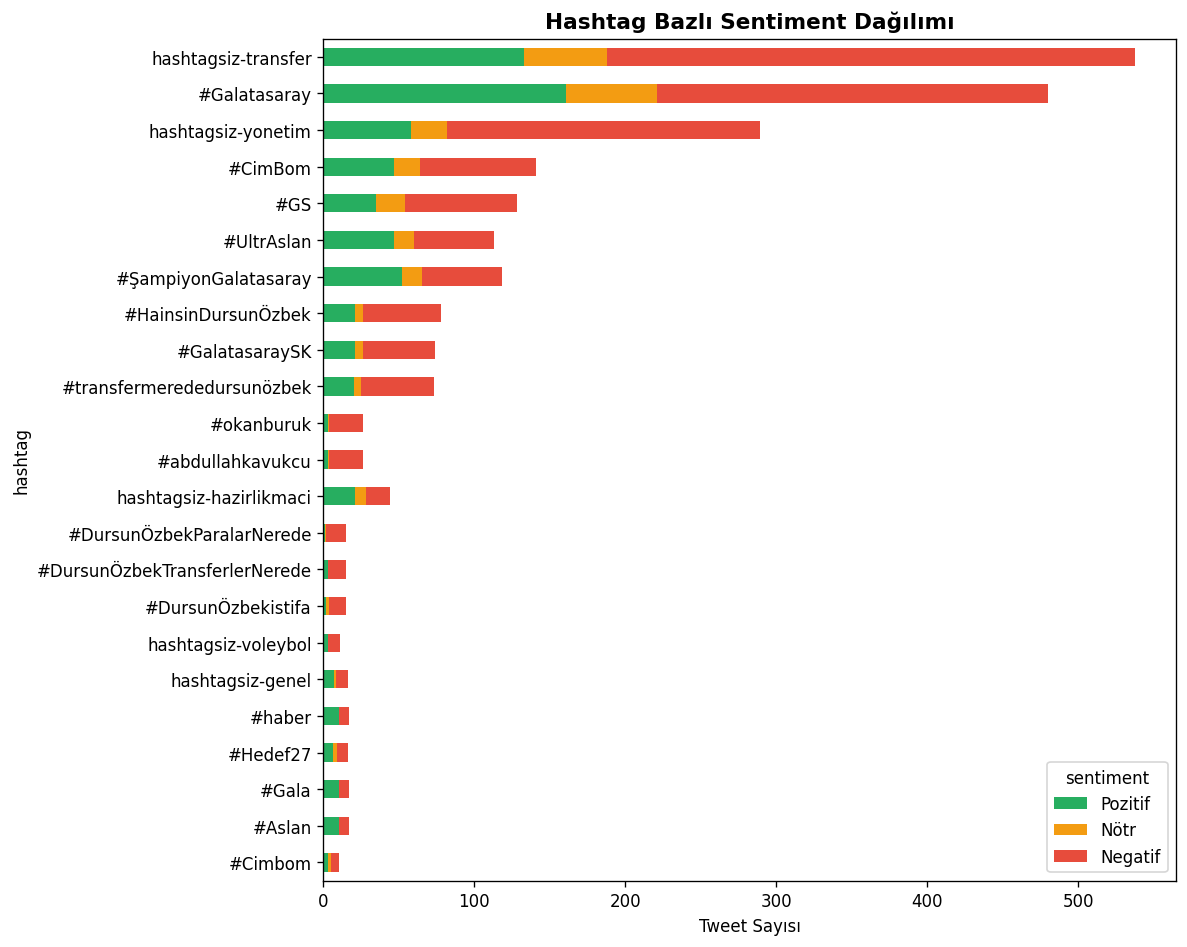

In [8]:
# search_term'i + ile böl, her hashtag'i ayrı satır yap
df_exp = df.copy()
df_exp["hashtag"] = df_exp["search_term"].str.split("+")
df_exp = df_exp.explode("hashtag")
df_exp["hashtag"] = df_exp["hashtag"].str.strip()

# En az 10 tweet olan hashtag'ler
hashtag_sentiment = (df_exp.groupby(["hashtag", "sentiment"])
                     .size()
                     .unstack(fill_value=0)
                     .reindex(columns=["Pozitif", "Nötr", "Negatif"], fill_value=0))
hashtag_sentiment = hashtag_sentiment[hashtag_sentiment.sum(axis=1) >= 10]
hashtag_sentiment = hashtag_sentiment.sort_values("Negatif", ascending=True)

hashtag_sentiment.plot(kind="barh", stacked=True, figsize=(10, 8),
                       color=["#27ae60", "#f39c12", "#e74c3c"])
plt.title("Hashtag Bazlı Sentiment Dağılımı", fontsize=13, fontweight="bold")
plt.xlabel("Tweet Sayısı")
plt.tight_layout()
plt.show()

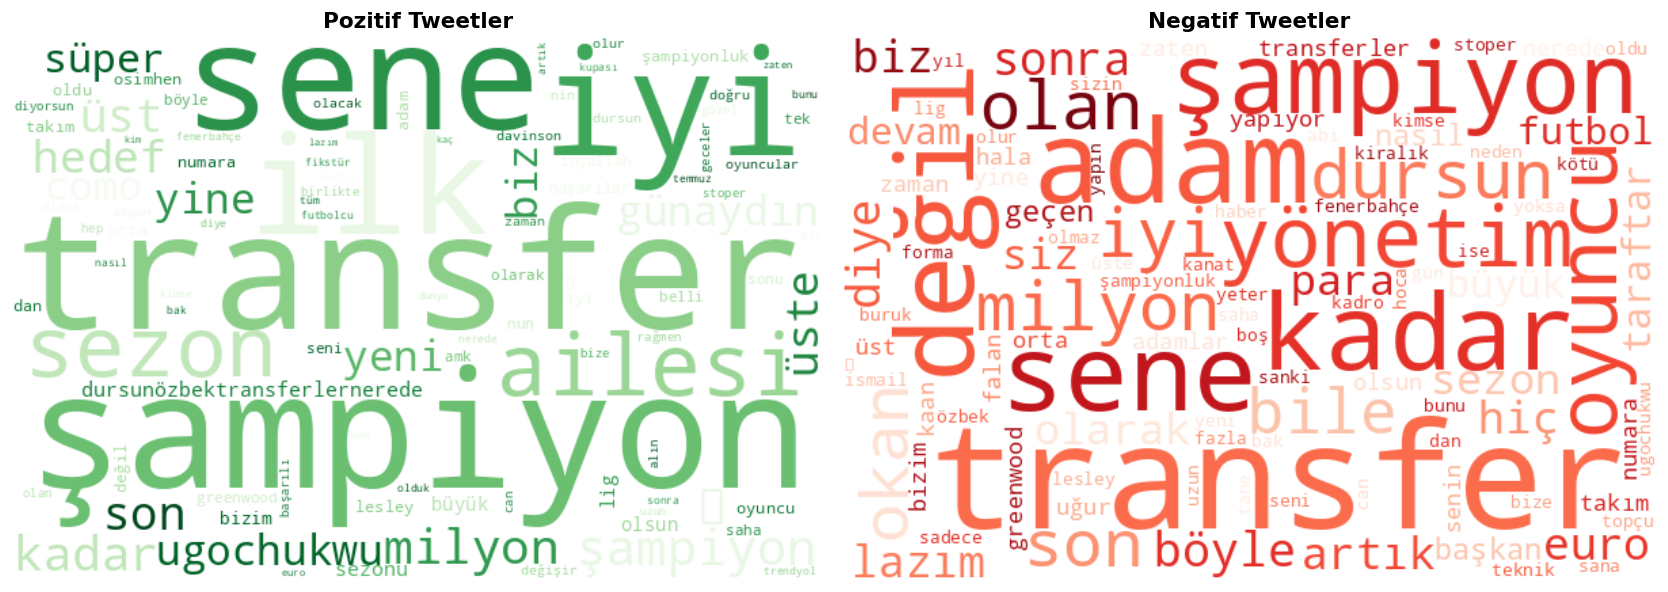

In [9]:
STOPWORDS = {"bir","bu","ve","da","de","ile","için","ne","o","ya","ki",
             "ama","çok","en","daha","var","yok","gibi","her","ben","sen",
             "rt","galatasaray","gs","cimbom","amp"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, label, cmap in zip(axes, ["Pozitif", "Negatif"], ["Greens", "Reds"]):
    words = " ".join(df[df["sentiment"] == label]["clean_text"].dropna())
    tokens = [w for w in words.split() if w not in STOPWORDS and len(w) > 2]
    freq = Counter(tokens)
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap=cmap, max_words=100, collocations=False)
    wc.generate_from_frequencies(freq)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{label} Tweetler", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()